<a href="https://colab.research.google.com/github/KVaishali810/Blast-Results-Parser/blob/main/blast_parser.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
!pip install biopython -q

from Bio import PDB
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully! ✅")

Libraries imported successfully! ✅


In [17]:
# ============================================
#   BLAST Results Parser & Annotator
#   Tools: pandas, matplotlib, requests
# ============================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import requests

# --- simulated BLAST results ---
# these mimic real BLAST XML output fields
blast_results = [
    {
        'hit_id'    : 'NM_007294.4',
        'hit_def'   : 'Homo sapiens BRCA1 DNA repair associated',
        'evalue'    : 1e-120,
        'identity'  : 98.5,
        'length'    : 450,
        'score'     : 850
    },
    {
        'hit_id'    : 'NM_000546.6',
        'hit_def'   : 'Homo sapiens TP53 tumor suppressor',
        'evalue'    : 1e-80,
        'identity'  : 92.3,
        'length'    : 380,
        'score'     : 720
    },
    {
        'hit_id'    : 'NM_005228.5',
        'hit_def'   : 'Homo sapiens EGFR epidermal growth factor',
        'evalue'    : 1e-45,
        'identity'  : 85.7,
        'length'    : 320,
        'score'     : 610
    },
    {
        'hit_id'    : 'NM_002467.6',
        'hit_def'   : 'Homo sapiens MYC proto-oncogene',
        'evalue'    : 1e-20,
        'identity'  : 72.1,
        'length'    : 280,
        'score'     : 450
    },
    {
        'hit_id'    : 'NM_000314.8',
        'hit_def'   : 'Homo sapiens PTEN tumor suppressor',
        'evalue'    : 1e-8,
        'identity'  : 61.4,
        'length'    : 210,
        'score'     : 320
    },
    {
        'hit_id'    : 'XM_003427.2',
        'hit_def'   : 'Unknown hypothetical protein',
        'evalue'    : 0.005,
        'identity'  : 48.2,
        'length'    : 150,
        'score'     : 180
    },
    {
        'hit_id'    : 'XM_009823.1',
        'hit_def'   : 'Uncharacterized protein LOC123456',
        'evalue'    : 0.8,
        'identity'  : 35.1,
        'length'    : 90,
        'score'     : 95
    },
]

# convert to dataframe
df = pd.DataFrame(blast_results)

print("===== Raw BLAST Results =====")
print(df.to_string(index=False))
print(f"\nTotal hits : {len(df)}")

===== Raw BLAST Results =====
     hit_id                                   hit_def        evalue  identity  length  score
NM_007294.4  Homo sapiens BRCA1 DNA repair associated 1.000000e-120      98.5     450    850
NM_000546.6        Homo sapiens TP53 tumor suppressor  1.000000e-80      92.3     380    720
NM_005228.5 Homo sapiens EGFR epidermal growth factor  1.000000e-45      85.7     320    610
NM_002467.6           Homo sapiens MYC proto-oncogene  1.000000e-20      72.1     280    450
NM_000314.8        Homo sapiens PTEN tumor suppressor  1.000000e-08      61.4     210    320
XM_003427.2              Unknown hypothetical protein  5.000000e-03      48.2     150    180
XM_009823.1         Uncharacterized protein LOC123456  8.000000e-01      35.1      90     95

Total hits : 7


In [18]:
# --- filter significant hits ---
evalue_threshold   = 1e-5
identity_threshold = 50.0

# apply both filters
filtered = df[
    (df['evalue']   < evalue_threshold) &
    (df['identity'] > identity_threshold)
]

rejected = df[
    (df['evalue']   >= evalue_threshold) |
    (df['identity'] <= identity_threshold)
]

print("===== Filtering Results =====")
print(f"Total hits     : {len(df)}")
print(f"Passed filter  : {len(filtered)}")
print(f"Rejected       : {len(rejected)}")

print("\n--- Significant Hits ---")
print(filtered[['hit_id', 'evalue',
                'identity', 'hit_def']].to_string(index=False))

print("\n--- Rejected Hits ---")
print(rejected[['hit_id', 'evalue',
                'identity', 'hit_def']].to_string(index=False))

===== Filtering Results =====
Total hits     : 7
Passed filter  : 5
Rejected       : 2

--- Significant Hits ---
     hit_id        evalue  identity                                   hit_def
NM_007294.4 1.000000e-120      98.5  Homo sapiens BRCA1 DNA repair associated
NM_000546.6  1.000000e-80      92.3        Homo sapiens TP53 tumor suppressor
NM_005228.5  1.000000e-45      85.7 Homo sapiens EGFR epidermal growth factor
NM_002467.6  1.000000e-20      72.1           Homo sapiens MYC proto-oncogene
NM_000314.8  1.000000e-08      61.4        Homo sapiens PTEN tumor suppressor

--- Rejected Hits ---
     hit_id  evalue  identity                           hit_def
XM_003427.2   0.005      48.2      Unknown hypothetical protein
XM_009823.1   0.800      35.1 Uncharacterized protein LOC123456


In [19]:
# --- annotate hits ---
annotations = {
    'NM_007294.4' : {
        'gene'     : 'BRCA1',
        'function' : 'DNA repair, tumor suppressor',
        'pathway'  : 'Homologous recombination',
        'disease'  : 'Breast/Ovarian cancer'
    },
    'NM_000546.6' : {
        'gene'     : 'TP53',
        'function' : 'Cell cycle regulation, apoptosis',
        'pathway'  : 'p53 signaling pathway',
        'disease'  : 'Li-Fraumeni syndrome, many cancers'
    },
    'NM_005228.5' : {
        'gene'     : 'EGFR',
        'function' : 'Cell growth, proliferation',
        'pathway'  : 'EGFR signaling pathway',
        'disease'  : 'Lung cancer, glioblastoma'
    },
    'NM_002467.6' : {
        'gene'     : 'MYC',
        'function' : 'Transcription factor, cell growth',
        'pathway'  : 'MYC targets',
        'disease'  : 'Burkitt lymphoma, many cancers'
    },
    'NM_000314.8' : {
        'gene'     : 'PTEN',
        'function' : 'Phosphatase, tumor suppressor',
        'pathway'  : 'PI3K/AKT signaling',
        'disease'  : 'Cowden syndrome, many cancers'
    },
}

# add annotations to filtered dataframe
filtered = filtered.copy()
filtered['gene']     = filtered['hit_id'].map(
                       lambda x: annotations.get(x, {}).get('gene', 'Unknown'))
filtered['function'] = filtered['hit_id'].map(
                       lambda x: annotations.get(x, {}).get('function', 'Unknown'))
filtered['pathway']  = filtered['hit_id'].map(
                       lambda x: annotations.get(x, {}).get('pathway', 'Unknown'))
filtered['disease']  = filtered['hit_id'].map(
                       lambda x: annotations.get(x, {}).get('disease', 'Unknown'))

print("===== Annotated BLAST Results =====\n")
for _, row in filtered.iterrows():
    print(f"Gene     : {row['gene']}")
    print(f"Accession: {row['hit_id']}")
    print(f"E-value  : {row['evalue']:.2e}")
    print(f"Identity : {row['identity']}%")
    print(f"Function : {row['function']}")
    print(f"Pathway  : {row['pathway']}")
    print(f"Disease  : {row['disease']}")
    print("-" * 45)

===== Annotated BLAST Results =====

Gene     : BRCA1
Accession: NM_007294.4
E-value  : 1.00e-120
Identity : 98.5%
Function : DNA repair, tumor suppressor
Pathway  : Homologous recombination
Disease  : Breast/Ovarian cancer
---------------------------------------------
Gene     : TP53
Accession: NM_000546.6
E-value  : 1.00e-80
Identity : 92.3%
Function : Cell cycle regulation, apoptosis
Pathway  : p53 signaling pathway
Disease  : Li-Fraumeni syndrome, many cancers
---------------------------------------------
Gene     : EGFR
Accession: NM_005228.5
E-value  : 1.00e-45
Identity : 85.7%
Function : Cell growth, proliferation
Pathway  : EGFR signaling pathway
Disease  : Lung cancer, glioblastoma
---------------------------------------------
Gene     : MYC
Accession: NM_002467.6
E-value  : 1.00e-20
Identity : 72.1%
Function : Transcription factor, cell growth
Pathway  : MYC targets
Disease  : Burkitt lymphoma, many cancers
---------------------------------------------
Gene     : PTEN
Accessi

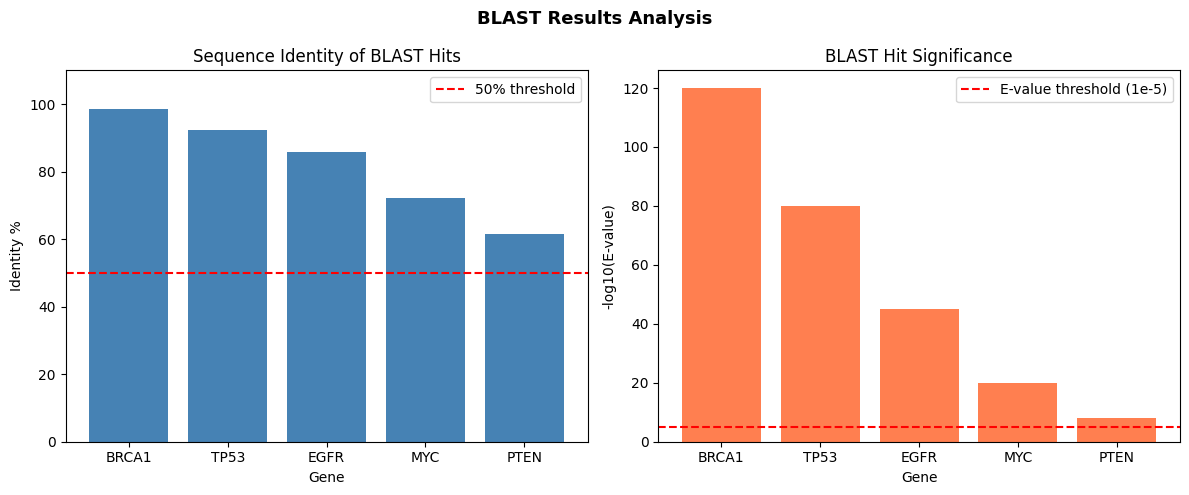

Plot saved 


In [20]:
# --- visualize ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

genes     = filtered['gene'].values
identity  = filtered['identity'].values
evalues   = [-np.log10(e) for e in filtered['evalue'].values]

# plot 1 - identity % per gene
axes[0].bar(genes, identity, color='steelblue')
axes[0].axhline(y=50, color='red', linestyle='--',
                label='50% threshold')
axes[0].set_xlabel('Gene')
axes[0].set_ylabel('Identity %')
axes[0].set_title('Sequence Identity of BLAST Hits')
axes[0].set_ylim(0, 110)
axes[0].legend()

# plot 2 - significance (-log10 evalue)
axes[1].bar(genes, evalues, color='coral')
axes[1].axhline(y=5, color='red', linestyle='--',
                label='E-value threshold (1e-5)')
axes[1].set_xlabel('Gene')
axes[1].set_ylabel('-log10(E-value)')
axes[1].set_title('BLAST Hit Significance')
axes[1].legend()

plt.suptitle('BLAST Results Analysis',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('blast_results.png')
plt.show()
print("Plot saved ")

In [21]:
# --- save final report ---
report = filtered[['gene', 'hit_id', 'evalue',
                   'identity', 'score',
                   'function', 'pathway', 'disease']]

report.to_csv('blast_report.csv', index=False)

print("===== Final Report Saved =====")
print(f"File     : blast_report.csv")
print(f"Hits     : {len(report)}")
print(f"Columns  : {list(report.columns)}")
print("\nPreview:")
print(report.to_string(index=False))

===== Final Report Saved =====
File     : blast_report.csv
Hits     : 5
Columns  : ['gene', 'hit_id', 'evalue', 'identity', 'score', 'function', 'pathway', 'disease']

Preview:
 gene      hit_id        evalue  identity  score                          function                  pathway                            disease
BRCA1 NM_007294.4 1.000000e-120      98.5    850      DNA repair, tumor suppressor Homologous recombination              Breast/Ovarian cancer
 TP53 NM_000546.6  1.000000e-80      92.3    720  Cell cycle regulation, apoptosis    p53 signaling pathway Li-Fraumeni syndrome, many cancers
 EGFR NM_005228.5  1.000000e-45      85.7    610        Cell growth, proliferation   EGFR signaling pathway          Lung cancer, glioblastoma
  MYC NM_002467.6  1.000000e-20      72.1    450 Transcription factor, cell growth              MYC targets     Burkitt lymphoma, many cancers
 PTEN NM_000314.8  1.000000e-08      61.4    320     Phosphatase, tumor suppressor       PI3K/AKT signaling 